### This notebook is soely used for different models, I have written a function that will able to evaluate all algorithms at one place. We can finetune every algorithm by passing evaluate_params arugment to evaluate_algorithms function

In [537]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [538]:
# Define a custom style with black background (matches presentation background)
grey_background_style = {
    'axes.facecolor': '#000000',  
    'figure.facecolor': '#000000',  
    'axes.edgecolor': 'white',  
    'axes.labelcolor': 'white', 
    'xtick.color': 'white', 
    'ytick.color': 'white',  
    'text.color': 'white',  
    'legend.facecolor': '#000000',  
    'legend.edgecolor': 'white'  
}

# Apply the custom style
plt.style.use(grey_background_style)

In [539]:
df = pd.read_csv('final_knn.csv',index_col=None)
df.head()

,relationship_name,victim_age,victim_race,victim_sex,victim_ethnicity,offender_age,offender_sex,offender_ethnicity,offender_race,location_name,offense_name,crime_against,ct_flag,hc_flag,offense_category_name,incident_hour,month_num,latitude,longitude
0,1,4.189655,5,1,1,3.465736,1,0,5,35,0,0,0,1,1,19.0,8.0,-74.693369,39.509659
1,23,4.025352,2,1,1,4.127134,0,1,2,31,1,1,1,0,12,9.0,8.0,-74.704769,39.477582
2,11,3.970292,5,1,1,4.262680,1,1,5,35,30,0,0,1,1,14.0,8.0,-74.650412,39.523961
3,3,3.555348,5,0,1,3.688879,1,0,5,35,30,0,0,1,1,23.0,8.0,-74.699584,39.491735
4,1,3.332205,2,1,1,3.295837,0,1,5,35,20,0,0,1,11,10.0,8.0,-74.652442,39.479984


In [540]:
null_counts = df.isnull().sum().sort_values(ascending=False)
null_counts[null_counts>1]

Series([], dtype: int64)

In [541]:
df['crime_against'].value_counts()

crime_against
0    27755
1    13179
Name: count, dtype: int64

In [542]:
df.columns

Index(['relationship_name', 'victim_age', 'victim_race', 'victim_sex',
       'victim_ethnicity', 'offender_age', 'offender_sex',
       'offender_ethnicity', 'offender_race', 'location_name', 'offense_name',
       'crime_against', 'ct_flag', 'hc_flag', 'offense_category_name',
       'incident_hour', 'month_num', 'latitude', 'longitude'],
      dtype='object')

In [543]:
from scikeras.wrappers import KerasClassifier

In [544]:

def evaluate_algoritms(X_train,X_test,y_train,y_test,evaluate_params,checktime=120,dont_train=[],verbose=True,scale=True):
    '''
    Arguments - 
    X_train - train features dataframe
    y_train - train target dataframe
    X_test - test features dataframe
    y_test - test target dataframe

    evaluate_params - {'model_name':hyper parameters to be used}
    checktime - If evaluation time >checktim(in s) then stop training that algorithm
    dont_train - The models in this list will not be  trained
    verbose - If true then prints accuracy score,time while execution
    scale - Tells whether to scale the data or not
    X_values - Takes the (X_train,y_train). Used when we want to pass X_train,y_train seperately instead of dataframes
    
    returns - 
    format of data - {'model_name':returned_value}
    accuracies - accuracies of all models
    trained_models - returns all trained models 
    time_taken - list of times taken by every algorithm
    predictions - list of predictions for every algorithm, useful for plotting cm
    test_values - list of (X_test,y_test) values for every algorithm, useful for plotting cm and evaluating

    '''
    from sklearn.naive_bayes import GaussianNB,MultinomialNB
    from sklearn.linear_model import LogisticRegression
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.svm import SVC 
    from sklearn.tree import DecisionTreeClassifier 
    from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import GridSearchCV
    from sklearn.model_selection import KFold
    from sklearn.metrics import accuracy_score,top_k_accuracy_score
    from timeout_decorator import timeout, TimeoutError
    from time import time
    import tensorflow as tf

    # trained_models = dict(zip(['naive_bayes','logistic_regresion','svc','decision_tree','random_forest','adaboost','gradient_boost'],
    #                       ['','','','','','','','','']))

    trained_models = {}
    accuracies = {}
    time_taken = {}
    predictions = {}
    test_values = {}

    if type(X_train) != type(pd.DataFrame()):
        X_train = pd.DataFrame(X_train)
        X_test = pd.DataFrame(X_test)
        y_train = pd.DataFrame(y_train)
        y_test = pd.DataFrame(y_test)
    class_weights = dict(y_train.value_counts()/y_train.shape[0])



    def print_verbose(message):
        if verbose:
            print(message)


    if 'naive_bayes' not in dont_train:
        #Naive bayes
        @timeout(checktime)
        def Naive_bayes(X_train,X_test,y_train,y_test):
            
            naive_bayes = GaussianNB()
            start_time = time()
            naive_bayes.fit(X_train,y_train)
            preds = naive_bayes.predict(X_test)
            end_time = time()
            time_taken= round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)
            return acc,naive_bayes,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['naive_bayes'],trained_models['naive_bayes'],time_taken['naive_bayes'] \
                ,predictions['naive_bayes'],test_values['naive_bayes']= Naive_bayes(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for Naive Bayes model {accuracies["naive_bayes"]:.2f}')
            print_verbose(f"time elapsed for Naive Bayes: {time_taken['naive_bayes']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for Naive Bayes.")
    
        


    if 'logistic_regression' not in dont_train:
        #Logistic Regression
        @timeout(checktime)
        def Logistic_Regression(X_train,X_test,y_train,y_test):

            if scale:

                from sklearn.preprocessing import StandardScaler
                lr_train_scaler = StandardScaler()
                lr_test_scaler = StandardScaler()
                lr_train_scaler.fit_transform(X_train)
                lr_test_scaler.fit_transform(X_test)

            params = evaluate_params['logistic_regression']

            log_regression = LogisticRegression(max_iter=params['max_iter'],solver=params['solver'],\
                                                class_weight=class_weights)
            start_time = time()
            log_regression.fit(X_train,y_train)
            preds = log_regression.predict(X_test)
            end_time = time()
            time_taken = round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)

            return acc,log_regression,time_taken,preds,(X_test,y_test)
        try:
            accuracies['logistic_regression'],trained_models['logistic_regression'],time_taken['logistic_regression'] \
                ,predictions['logistic_regression'],test_values['logistic_regression']\
                    = Logistic_Regression(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for Logistic Regression model {accuracies["logistic_regression"]:.2f}')
            print_verbose(f"time elapsed for Logistic Regression: {time_taken['logistic_regression']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for Logistic Regression.")

    if 'KNN' not in dont_train:
        #KNN
        @timeout(checktime)
        def KNN(X_train,X_test,y_train,y_test):

            if scale:
                knn_scaler = StandardScaler()
                X_train = knn_scaler.fit_transform(X_train)
                X_test = knn_scaler.transform(X_test)

            params = evaluate_params['knn']

            knn = KNeighborsClassifier(weights=params['weighted'],n_neighbors=params['n_neighbors'])
            start_time = time()
            knn.fit(X_train,y_train)
            preds = knn.predict(X_test)
            end_time = time()
            time_taken = round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)
            return acc,knn,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['knn'],trained_models['knn'],time_taken['knn'] \
                ,predictions['knn'],test_values['knn']= KNN(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for KNN model {accuracies["knn"]:.2f}')
            print_verbose(f"time elapsed for KNN: {time_taken['knn']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for KNN.")
        
        
    
    if 'svm' not in dont_train:
        #Svm
        @timeout(checktime)
        def Support_vector_classifier(X_train,X_test,y_train,y_test):

            if scale:
                svm_scaler = StandardScaler()
                X_train = svm_scaler.fit_transform(X_train)
                X_test = svm_scaler.transform(X_test)

            params = evaluate_params['svm']
        
            svc = SVC(kernel=params['kernel'],C=params['C'],gamma=params['gamma'],class_weight=class_weights)
            start_time = time()
            svc.fit(X_train,y_train)
            preds = svc.predict(X_test)
            end_time = time()
            time_taken = round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)
            return acc,svc,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['svm'] ,trained_models['svm'],time_taken['svm'] \
                ,predictions['svm'],test_values['svm']= Support_vector_classifier(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for Support vector classifier {accuracies["svm"] :.2f}')
            print_verbose(f"time elapsed for Support Vector Machine: {time_taken['svm']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for SVM.")

        

    if 'decision_tree' not in dont_train:
        #Decision tree
        @timeout(checktime)
        def Decision_tree(X_train,X_test,y_train,y_test):

            params = evaluate_params['decision_tree']

#             max_depth': 10,
#  'min_samples_leaf': 2,
#  'min_samples_split': 2}

            decision_tree = DecisionTreeClassifier(random_state=42,class_weight=class_weights,\
                                                   criterion=params['criterion'],max_depth=params['max_depth'],\
                                      min_samples_split=params['min_samples_split'],min_samples_leaf=params['min_samples_leaf'])
            start_time = time()
            decision_tree.fit(X_train,y_train)
            preds = decision_tree.predict(X_test)
            end_time = time()
            time_taken = round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)
            return acc,decision_tree,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['decision_tree'],trained_models['decision_tree'],time_taken['decision_tree'] \
                ,predictions['decision_tree'],test_values['decision_tree']= Decision_tree(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for Decision_tree {accuracies["decision_tree"]:.2f}')
            print_verbose(f"time elapsed for Decision Tree Classifier: {time_taken['decision_tree']}")
        except TimeoutError:
            print_verbose("Traninng took too long. Stopping the process for Decision_tree")


    if 'random_forest' not in dont_train:

        #Random_forest
        @timeout(checktime)
        def Random_Forest(X_train,X_test,y_train,y_test):

            params = evaluate_params['random_forest']

            random_forest =  RandomForestClassifier(random_state=42,class_weight=class_weights,\
                                     n_estimators=params['n_estimators'],criterion=params['criterion'],max_depth=params['max_depth'],\
                                      min_samples_split=params['min_samples_split'],min_samples_leaf=params['min_samples_leaf'])
            start_time = time()
            random_forest.fit(X_train,y_train)
            preds = random_forest.predict(X_test)
            end_time = time()
            time_taken = round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)
            return acc,random_forest,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['random_forest'],trained_models['random_forest'],time_taken['random_forest'] \
                ,predictions['random_forest'],test_values['random_forest'] = Random_Forest(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for Random Forest {accuracies["random_forest"]:.2f}')
            print_verbose(f"time elapsed for Random Forest Classifier: {time_taken['random_forest']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for Random Forest")


    
    if 'adaboost' not in dont_train:

        #Adaboost
        @timeout(checktime)
        def Adaboost(X_train,X_test,y_train,y_test):

            adaboost = AdaBoostClassifier(random_state=42,estimator=DecisionTreeClassifier())
            start_time = time()
            adaboost.fit(X_train,y_train)
            preds = adaboost.predict(X_test)
            end_time = time()
            time_taken = round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)
            return acc,adaboost,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['adaboost'],trained_models['adaboost'],time_taken['adaboost'] \
                ,predictions['adaboost'],test_values['adaboost'] = Adaboost(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for Adaboost {accuracies["adaboost"]:.2f}')
            print_verbose(f"time elapsed for Adaboost: {time_taken['adaboost']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for Adaboost")
    

    if 'gradientboost' not in dont_train:
        #gradientboost
        @timeout(checktime)
        def Gradientboost(X_train,X_test,y_train,y_test):

            gradientboost = GradientBoostingClassifier(random_state=42)
            start_time = time()
            gradientboost.fit(X_train,y_train)
            preds = gradientboost.predict(X_test)
            end_time = time()
            time_taken = round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)
            return acc,gradientboost,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['gradientboost'],trained_models['gradientboost'],time_taken['gradientboost'] \
                ,predictions['gradientboost'],test_values['gradientboost'] = Gradientboost(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for Gradient Boosting {accuracies["gradientboost"]:.2f}')
            print_verbose(f"time elapsed for Gradientboost: {time_taken['gradientboost']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for Gradientboosting")


    if 'ann' not in dont_train:
        #ann
        @timeout(checktime)
        def ANN(X_train,X_test,y_train,y_test):
        
            # Standardize the data
            if scale:
                ann_scaler = StandardScaler()
                X_train = ann_scaler.fit_transform(X_train)
                X_test= ann_scaler.transform(X_test)
            
            def build_model():

                # build the ANN model
                ann_model = tf.keras.models.Sequential()
                ann_model.add(tf.keras.layers.Dense(units=128, activation='relu', input_dim=X_train.shape[1]))
                ann_model.add(tf.keras.layers.Dense(units=64, activation='relu'))
                ann_model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

                # compile the model
                ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

                return ann_model
            
            ann_model = KerasClassifier(model=build_model, epochs=10, batch_size=32, verbose=0)

            start_time = time()
            ann_model.fit(X_train, y_train,validation_data=(X_test, y_test),verbose=0)
            preds = ann_model.predict(X_test,verbose=0)
            preds = np.round(preds.squeeze(),decimals=0)
            end_time = time()
            time_taken = end_time - start_time
            acc = accuracy_score(y_test, preds)

            return acc,ann_model,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['ann'],trained_models['ann'],time_taken['ann'] \
                ,predictions['ann'],test_values['ann'] = ANN(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for ANN {accuracies["ann"]:.2f}')
            print_verbose(f"time elapsed for ANN: {time_taken['ann']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for ANN")


    return accuracies,trained_models,time_taken,predictions,test_values



In [545]:
# from sklearn.preprocessing import LabelEncoder

# # Assuming 'df' is your DataFrame

# # Identify categorical columns
# categorical_columns = df.select_dtypes(include=['object']).columns

# # Initialize LabelEncoder
# label_encoder = LabelEncoder()

# # Encode categorical variables
# for column in categorical_columns:
#     df[column] = label_encoder.fit_transform(df[column])



In [546]:
df.columns

Index(['relationship_name', 'victim_age', 'victim_race', 'victim_sex',
       'victim_ethnicity', 'offender_age', 'offender_sex',
       'offender_ethnicity', 'offender_race', 'location_name', 'offense_name',
       'crime_against', 'ct_flag', 'hc_flag', 'offense_category_name',
       'incident_hour', 'month_num', 'latitude', 'longitude'],
      dtype='object')

##### Plot confusion matrix

In [547]:
def plot_confusion_matrix(df,predictions,test_values,display_cr=False):
    '''
    df - data dataframe
    predictions - predictions from our models({'model_name':predictions})
    test_values - list of tuples of (X_test,y_test) for each model 
    display_cr - boolean value to tell whether to print classification_report or not

    '''
    from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix,classification_report,accuracy_score

    fig,axs = plt.subplots(int(np.ceil(len(predictions)/2)),2,figsize=(20,12))
    axs = axs.ravel()
    for ax in axs[len(predictions):]:
        ax.axis('off')
    axs = axs[:len(predictions)]
        
    display_labels = df['crime_against'].map(lambda x: 'property' if x == 0 else 'person').unique()


    for (preds, y_true), ax in zip(zip(predictions.items(),test_values.items()), axs):
        model_name = preds[0]
        y_pred = preds[1]
        y_true = y_true[1][1]

        cm = confusion_matrix(y_true, y_pred)

        # Plot confusion matrix on the subplot
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
        disp.plot(cmap='Blues', values_format='d',ax=ax)

        ax.set_title(f"Confusion Matrix - {model_name}")

        # Calculate classification report
        cr = classification_report(y_true, y_pred, target_names=display_labels, output_dict=True)

        classification_text = "\n".\
        join([f"{label}:\n Precision: {round(cr[label]['precision'],3)}\n Recall: {round(cr[label]['recall'],3)}\n F1-Score: {round(cr[label]['f1-score'],3)}" for label in display_labels])
        classification_text += f"\n\nAccuracy: {round(accuracy_score(y_true, y_pred),3)}"  # Add accuracy information

        ax.text(2, 0.5, classification_text, transform=ax.transAxes, fontsize=11, verticalalignment='center')

        if display_cr:

            print(f'---- Classification report for {model_name} ----')
            print(classification_report(y_true,y_pred,target_names=display_labels))

    plt.tight_layout()
    plt.show()



##### Initial model 

In [548]:
# our model is based on features excluding drop features
drop_features = ['crime_against', 'offense_name', 'offense_category_name','ct_flag','hc_flag']
# shuffle data 
df = df.sample(frac=1, random_state=42)
X = df.drop(drop_features,axis=1)
y = df['crime_against']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

##### Finding Hyperparameters

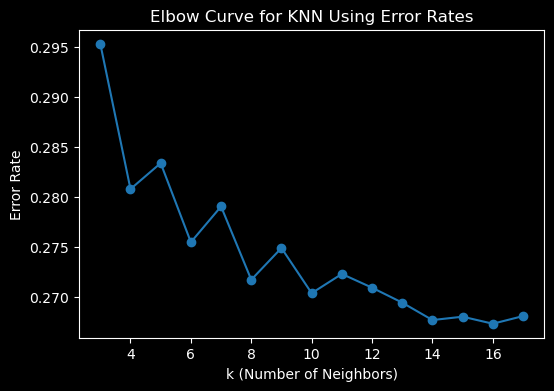

In [491]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

k_values = np.arange(3,18)
errors = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Invert the accuracy to get error rate
    error = 1 - cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy').mean()
    errors.append(error)

# Plotting the elbow curve for error rates
plt.figure(figsize=(6,4))
plt.plot(k_values, errors, 'o-')
plt.title('Elbow Curve for KNN Using Error Rates')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Error Rate')
plt.show()


In [492]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
params = {
    'max_depth': [8,10,12],
    'min_samples_split': [2,3,4],
    'min_samples_leaf': [1,2,3],
    'criterion':['gini','entropy']
}

dt = DecisionTreeClassifier(random_state=42)

grid_dt = GridSearchCV(dt, param_grid=params, cv=5, 
                          scoring='accuracy').fit(X_train, y_train)

In [493]:
grid_dt.best_params_

{'criterion': 'gini',
 'max_depth': 8,
 'min_samples_leaf': 1,
 'min_samples_split': 4}

In [388]:
from sklearn.ensemble import RandomForestClassifier
params = {
    'n_estimators': [100,150,200],
    'max_depth': [8,10,12],
    'min_samples_split': [2,3,4],
    'min_samples_leaf': [1,2,3],
    'criterion':['gini','entropy']
}

rf = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(rf, param_grid=params, cv=5, 
                          scoring='accuracy').fit(X_train, y_train)

In [389]:
grid_rf.best_params_

{'criterion': 'gini',
 'max_depth': 12,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

#### Evaluating nine algorithms

In [549]:
evaluate_params = {'logistic_regression':{'solver':'lbfgs','max_iter':1000},
                   'knn':{'n_neighbors': 8, 'p': 1, 'weighted': 'distance'},
                   'svm':{'kernel':'rbf','C':5,'gamma':'auto'},
                   'decision_tree':{'criterion': 'gini','max_depth': 8,'min_samples_leaf': 1,'min_samples_split': 4},
                   'random_forest':{'criterion': 'gini','max_depth': 12,'min_samples_leaf': 1,\
                                    'min_samples_split': 2,'n_estimators': 200}}

accuracies,trained_models,time_taken,predictions,test_values \
= evaluate_algoritms(X_train,X_test,y_train,y_test,evaluate_params,checktime=120,dont_train=[],scale=True)

Accuracy for Naive Bayes model 0.68
time elapsed for Naive Bayes: 0.07
Accuracy for Logistic Regression model 0.68
time elapsed for Logistic Regression: 1.08
Accuracy for KNN model 0.72
time elapsed for KNN: 1.31
Accuracy for Support vector classifier 0.71
time elapsed for Support Vector Machine: 29.43
Accuracy for Decision_tree 0.72
time elapsed for Decision Tree Classifier: 0.1
Accuracy for Random Forest 0.74
time elapsed for Random Forest Classifier: 4.34
Accuracy for Adaboost 0.68
time elapsed for Adaboost: 0.21
Accuracy for Gradient Boosting 0.76
time elapsed for Gradientboost: 3.9
Accuracy for ANN 0.73
time elapsed for ANN: 6.2521750926971436


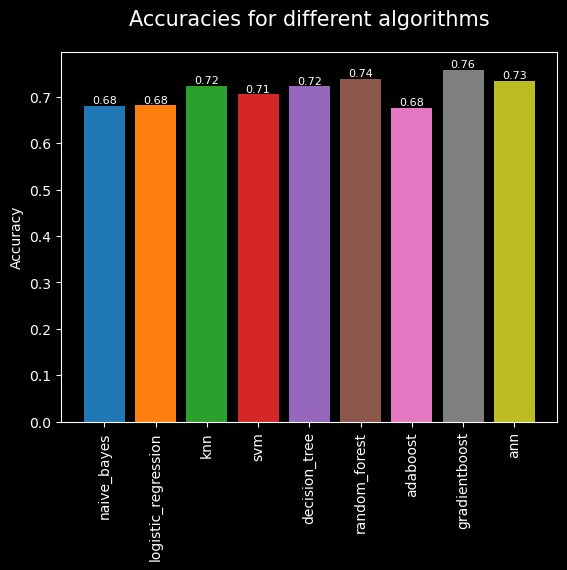

In [550]:
bars = plt.bar(accuracies.keys(), accuracies.values(),color=[plt.get_cmap('tab20')(i) for i in range(0,2*len(accuracies),2)])
ax = plt.gca()
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', rotation=90)  
ax.set_title("Accuracies for different algorithms",color='white',fontsize=15,y=1.05)
# ax.text(-0.65, 0.77, , fontsize=10)

for bar, acc in zip(bars, accuracies.values()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{acc:.2f}', ha='center', va='bottom', fontsize=8)


In [551]:
[plt.get_cmap('tab20')(i) for i in range(0,len(time_taken),2)]

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
 (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0)]

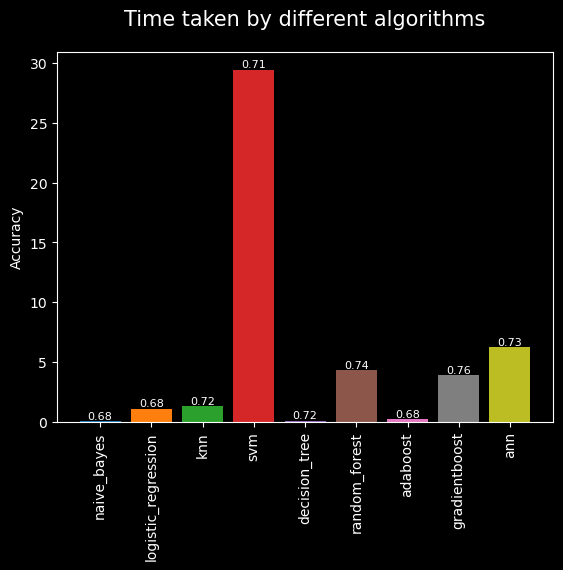

In [552]:
bars = plt.bar(time_taken.keys(), time_taken.values(),color=[plt.get_cmap('tab20')(i) for i in range(0,2*len(time_taken),2)])
ax = plt.gca()
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', rotation=90)  
ax.set_title("Time taken by different algorithms",color='white',fontsize=15,y=1.05)
# ax.text(-0.65, 0.77, , fontsize=10)

for bar, acc in zip(bars, accuracies.values()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{acc:.2f}', ha='center', va='bottom', fontsize=8)


---- Classification report for naive_bayes ----
              precision    recall  f1-score   support

      person       0.72      0.87      0.79      5536
    property       0.51      0.28      0.36      2651

    accuracy                           0.68      8187
   macro avg       0.61      0.58      0.57      8187
weighted avg       0.65      0.68      0.65      8187

---- Classification report for logistic_regression ----
              precision    recall  f1-score   support

      person       0.68      0.99      0.81      5536
    property       0.70      0.03      0.06      2651

    accuracy                           0.68      8187
   macro avg       0.69      0.51      0.43      8187
weighted avg       0.69      0.68      0.56      8187

---- Classification report for knn ----
              precision    recall  f1-score   support

      person       0.76      0.86      0.81      5536
    property       0.60      0.44      0.51      2651

    accuracy                          

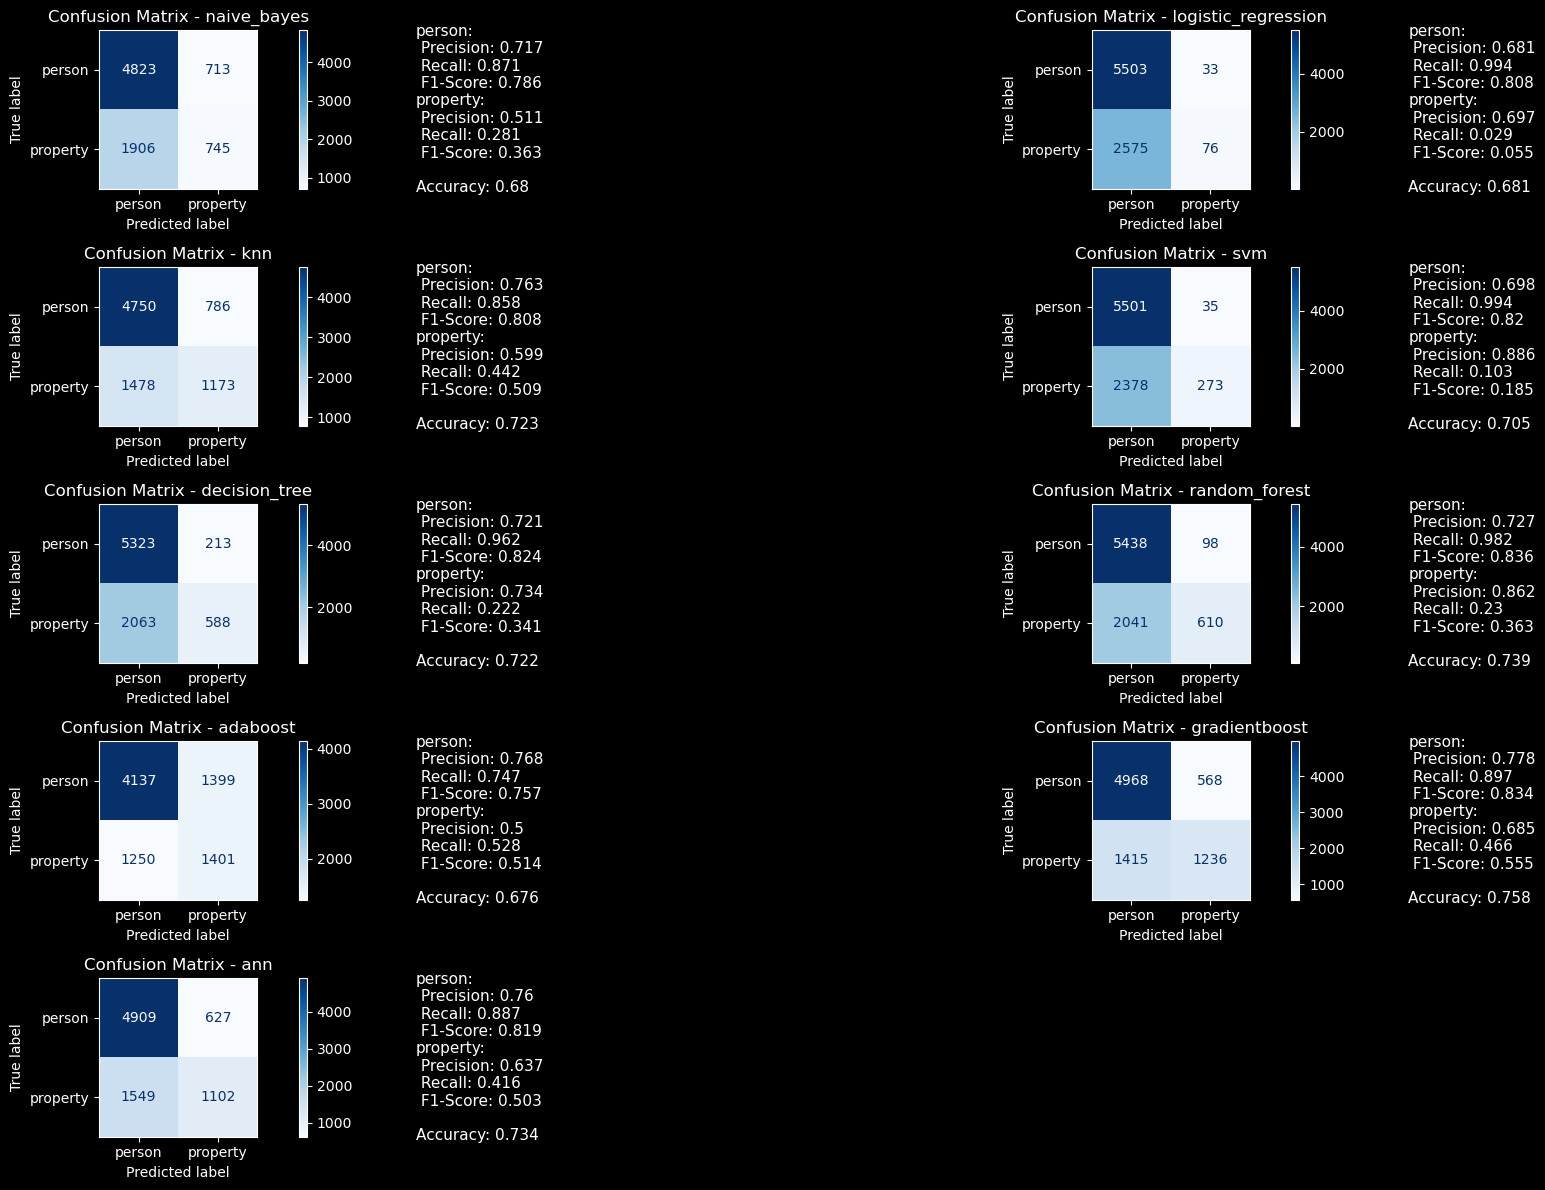

In [553]:
plot_confusion_matrix(df,predictions,test_values,display_cr=True)

#### Feature importance

Text(0.5, 1.05, 'Feature importances for different algorithms')

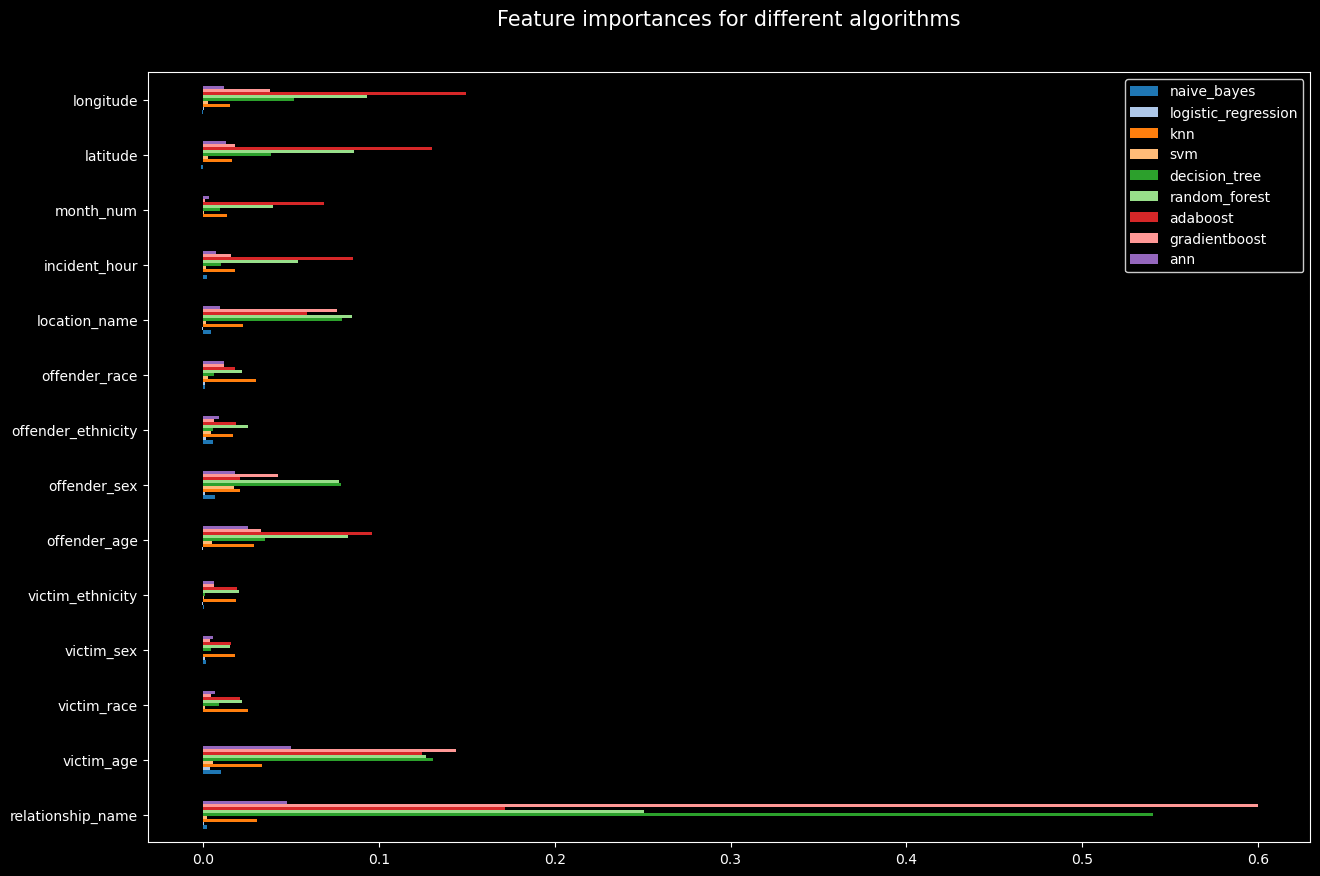

In [499]:
from sklearn.inspection import permutation_importance

# store feature importances for each model
feature_importances = {}

for model_name, model in trained_models.items():
    X_test = test_values[model_name][0]
    y_test = test_values[model_name][1]
    if hasattr(model, 'feature_importances_'):
        # random Forest and AdaBoost have feature_importances_ attribute
        feature_importances[model_name] = model.feature_importances_
    else:
        # for models without direct feature importances, use permutation importance
        result = permutation_importance(model, X_test, y_test, n_repeats=3, random_state=42)
        feature_importances[model_name] = result.importances_mean


feature_importances_df = pd.DataFrame(feature_importances,index=X_train.columns)
ax = feature_importances_df.plot(kind='barh',figsize=(15,10),color=[plt.get_cmap('tab20')(i) for i in range(len(accuracies))])
ax.set_title('Feature importances for different algorithms',fontsize=15,color='white',y=1.05)


In [500]:
def plot_algorithm_accuracies(accuracies, ax,dropped_features):
    '''
    accuracies - Accuracies from all models to plot
    ax - current axes to plot
    dropped_features - feature names that are dropped

    Plots the bar plot and each bar height represents accuracy for the model
    '''
    if len(dropped_features)==1:
        dropped_features.append('')
    bars = ax.bar(accuracies.keys(), accuracies.values(),color=[plt.get_cmap('tab20')(i) for i in range(0,2*len(accuracies),2)])
    ax.set_ylabel('Accuracy')
    ax.set_title(f'dropped_features={dropped_features[1:]}',fontsize=12,color='white',y=1)
    ax.tick_params(axis='x', rotation=90)  
    # ax.text(-0.65, 0.77, , fontsize=10)

    for bar, acc in zip(bars, accuracies.values()):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{acc:.2f}', ha='center', va='bottom', fontsize=8)


In [501]:
def plot_algoritm_time_taken(time_taken,ax,dropped_features):

    '''
    accuracies - Accuracies from all models to plot
    ax - current axes to plot
    dropped_features - feature names that are dropped

    Plots the bar plot and each bar height represents accuracy for the model
    '''
        
    if len(dropped_features)==1:
        dropped_features.append('')

    bars = ax.bar(time_taken.keys(), time_taken.values(),color=[plt.get_cmap('tab20')(i) for i in range(0,2*len(accuracies),2)])
    ax.set_ylabel('Time_taken')
    ax.set_title(f'dropped_features={dropped_features[1:]}',fontsize=12,color='white',y=1)
    ax.tick_params(axis='x', rotation=90)  
    # ax.text(-0.65, 0.77, , fontsize=10)

    for bar, acc in zip(bars, time_taken.values()):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{acc:.2f}', ha='center', va='bottom', fontsize=8)

#### Feature importance and selection

In [502]:
import matplotlib.pyplot as plt

def evaluate_and_plot(df,drop_features_list=None,plot_times=False):

    '''
    Args - 
    df - data dataframe
    drop_features_list - features names that needs to be dropped
    plot_times - whether to plot_times for algorithms or not

    returns - 
    trail_results - All our outputs from the trained models
    
    '''
    
    trail_results = []
    evaluate_params = {'logistic_regression':{'solver':'lbfgs','max_iter':1000},
                    'knn':{'n_neighbors': 8, 'p': 1, 'weighted': 'distance'},
                    'svm':{'kernel':'rbf','C':5,'gamma':'auto'},
                    'decision_tree':{'criterion': 'gini','max_depth': 8,'min_samples_leaf': 1,'min_samples_split': 4},
                    'random_forest':{'criterion': 'gini','max_depth': 12,'min_samples_leaf': 1,\
                                        'min_samples_split': 2,'n_estimators': 200}}
        

    def evaluate(df, drop_features, ax1, ax2,plot_times,evaluate_params=None,verbose=True,checktime=120):
        df = df.sample(frac=1, random_state=42)
        X = df.drop(drop_features, axis=1)
        y = df[drop_features[0]]

        X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

        accuracies, trained_models,time_taken,predictions,test_values = \
            evaluate_algoritms(X_train,X_test,y_train,y_test,evaluate_params,checktime=checktime,dont_train=[],\
                               scale=True,verbose=verbose)
        
        plot_algorithm_accuracies(accuracies,ax1,drop_features)
        if plot_times:
            plot_algoritm_time_taken(time_taken, ax2,drop_features)
        
        return accuracies,trained_models,time_taken,predictions,test_values

    fig1, axs1 = plt.subplots(2, 2, figsize=(15, 10))
    axs1 = axs1.ravel()

    if plot_times:
        fig2, axs2 = plt.subplots(2, 2, figsize=(15, 10))
        axs2 = axs2.ravel()
    else:
        axs2 = [None]*4

    # List of drop_features for each iteration
    if not drop_features_list:
        drop_features_list = [
            ['crime_against'],
            ['crime_against', 'offense_name', 'offense_category_name'],
            ['crime_against', 'offense_name', 'offense_category_name','ct_flag'],
            ['crime_against', 'offense_name', 'offense_category_name','ct_flag','hc_flag']
        ]

    # Iterate over drop_features_list and axs
    for i,drop_features in enumerate(drop_features_list):
        trail_results.append(evaluate(df, drop_features, axs1[i],axs2[i],evaluate_params=evaluate_params, verbose=False,plot_times=plot_times))

    fig1.tight_layout(rect=[0, 0, 1, 0.96])
    if plot_times:
        fig2.tight_layout(rect=[0, 0, 1, 0.96])


    plt.show()

    return trail_results

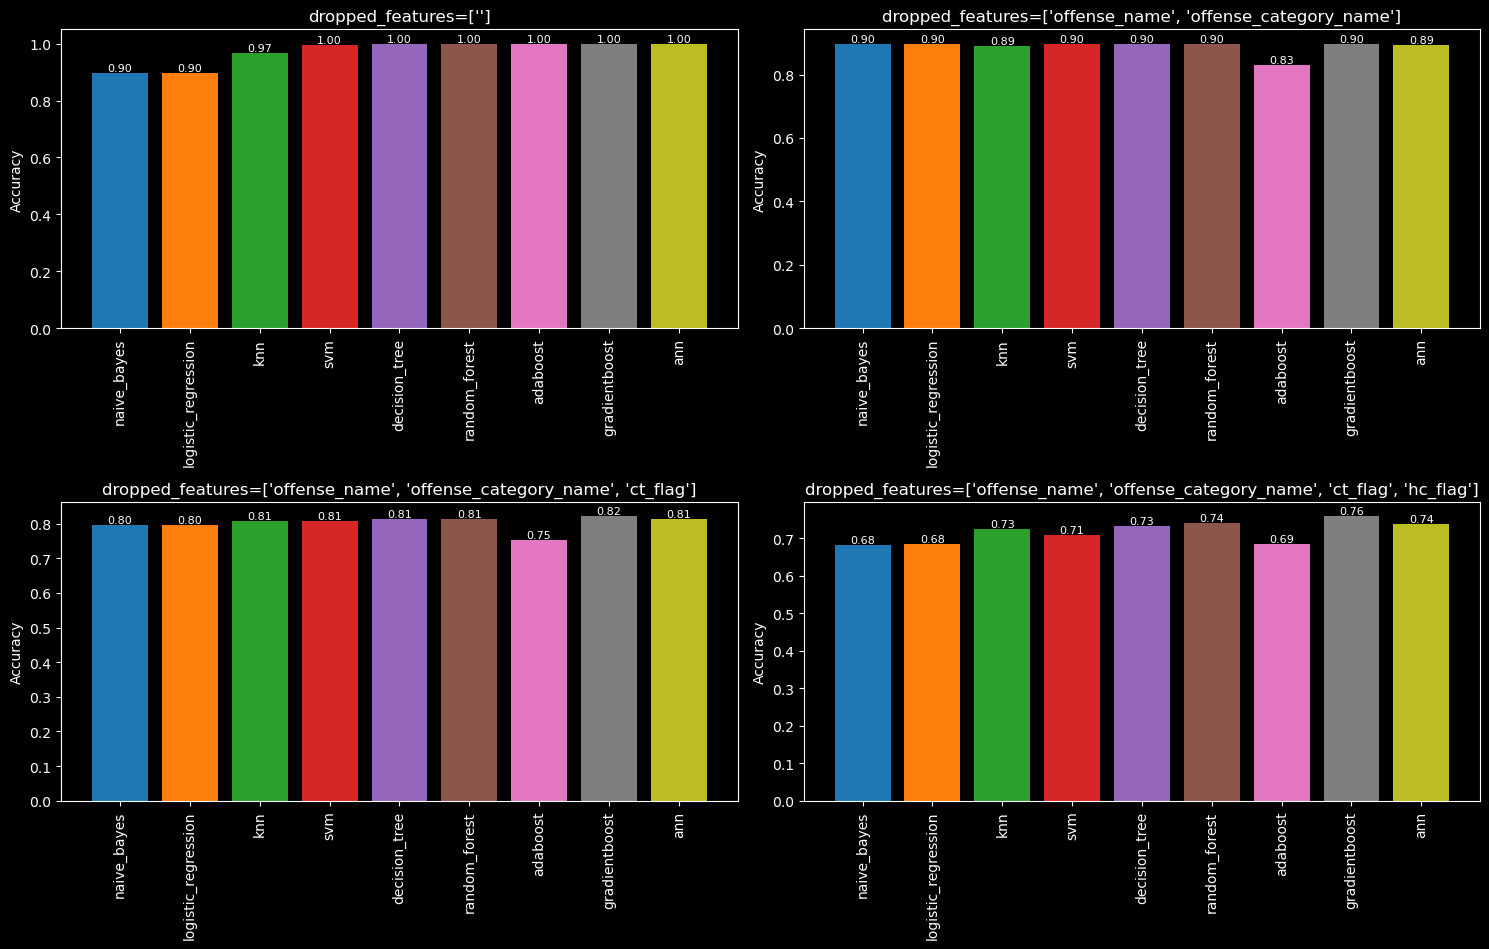

In [503]:
trail_results = evaluate_and_plot(df)

##### Downsampling and upsampling the data based on target variable crime_against

In [517]:
import pandas as pd


df_majority = df[df['crime_against'] == False]
df_minority = df[df['crime_against'] == True]

# Calculate the upsampling factor to balance the classes
upsample_factor = len(df_majority) // len(df_minority)

# Upsample the minority class
df_upsampled = pd.concat([df_minority] * upsample_factor + [df_majority], ignore_index=True)

# Shuffle the DataFrame to randomize the order of instances
df_upsampled = df_upsampled.sample(frac=1).reset_index(drop=True)


#downsample the majority class
df_downsampled = pd.concat([df_majority.sample(len(df_minority)), df_minority], ignore_index=True)


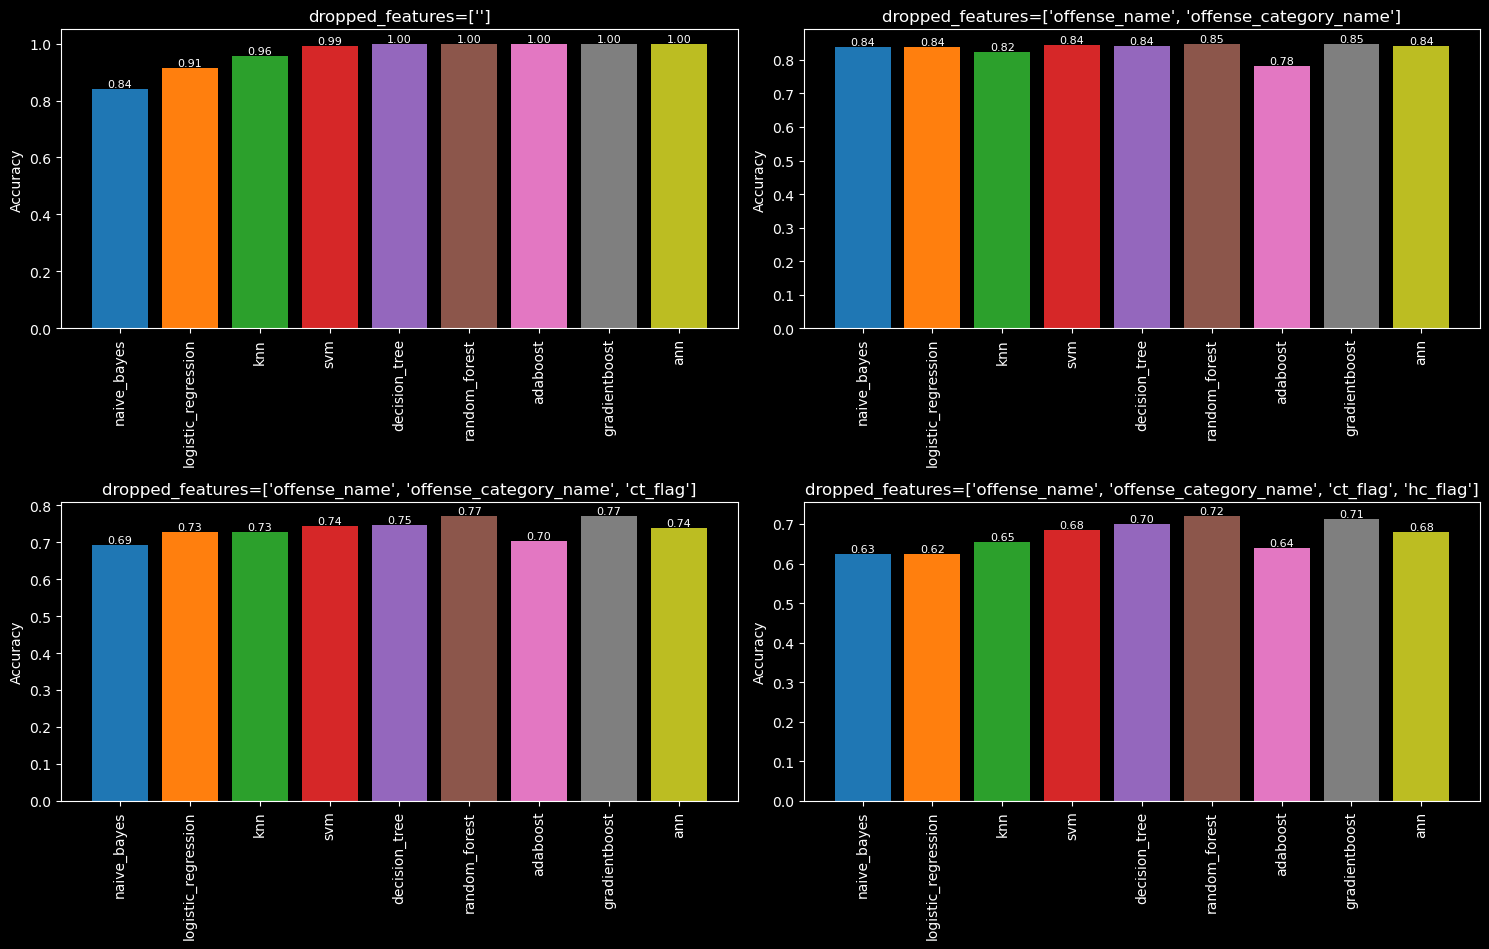

In [518]:
downsample_result = evaluate_and_plot(df_downsampled)

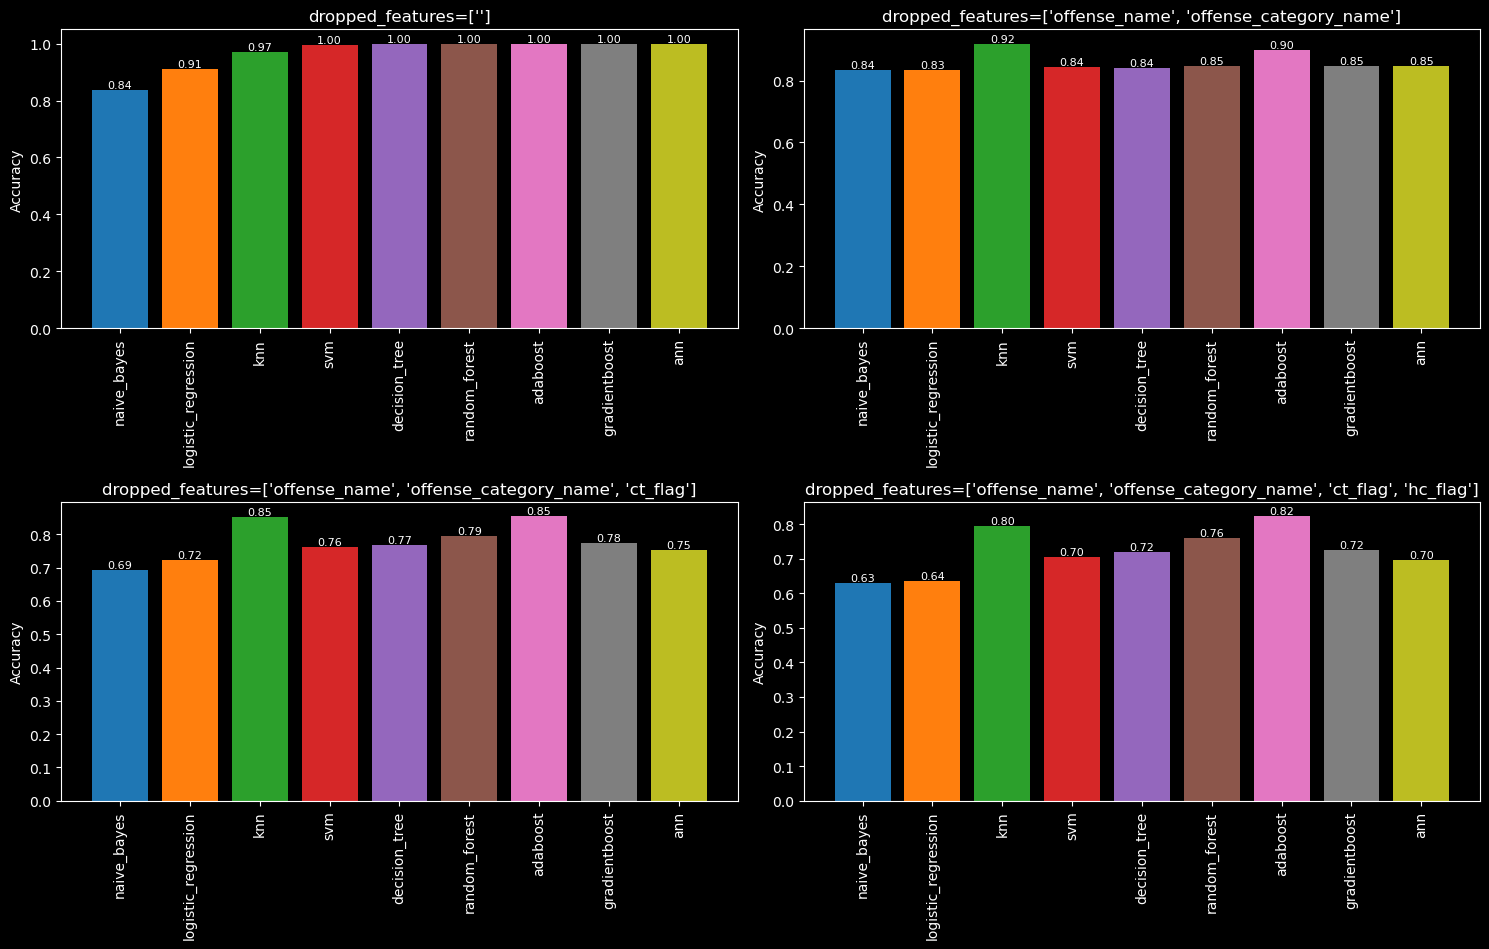

In [519]:
upsampled_result = evaluate_and_plot(df_upsampled)

#### Use cross validation to check the robustness of oversampling using dataframe sampling

Accuracy for Naive Bayes model 0.63
time elapsed for Naive Bayes: 0.03
Accuracy for Logistic Regression model 0.64
time elapsed for Logistic Regression: 0.65
Accuracy for KNN model 0.79
time elapsed for KNN: 1.62
Accuracy for Support vector classifier 0.72
time elapsed for Support Vector Machine: 56.01
Accuracy for Decision_tree 0.72
time elapsed for Decision Tree Classifier: 0.13
Accuracy for Random Forest 0.77
time elapsed for Random Forest Classifier: 6.17
Accuracy for Adaboost 0.82
time elapsed for Adaboost: 0.3
Accuracy for Gradient Boosting 0.73
time elapsed for Gradientboost: 7.14
Accuracy for ANN 0.71
time elapsed for ANN: 8.301082849502563
43290 10823
Accuracy for Naive Bayes model 0.63
time elapsed for Naive Bayes: 0.04
Accuracy for Logistic Regression model 0.64
time elapsed for Logistic Regression: 0.76
Accuracy for KNN model 0.80
time elapsed for KNN: 1.68
Accuracy for Support vector classifier 0.70
time elapsed for Support Vector Machine: 59.36
Accuracy for Decision_tree 

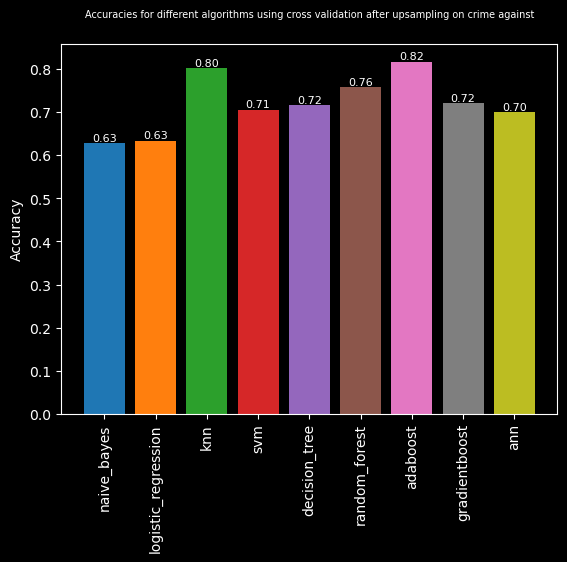

In [520]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mean_accuracies = []

X = df_upsampled.drop(drop_features, axis=1)
y = df_upsampled['crime_against']

for i, (train_index, test_index) in enumerate(kf.split(X)):
    # Split the data into training and testing sets using the indices provided by kf.split
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    upsampled_accuracies, upsampled_trained_models, upsampled_time_taken, upsampled_predictions, upsampled_test_values = \
    evaluate_algoritms(X_train, X_test, y_train, y_test, evaluate_params, checktime=120, dont_train=[], scale=True,verbose=True)
    
    print(len(X_train),len(X_test))

    mean_accuracies.append(upsampled_accuracies)

mean_accuracies = {model: sum(d[model] for d in mean_accuracies) / len(mean_accuracies) for model in mean_accuracies[0]}


bars = plt.bar(mean_accuracies.keys(), mean_accuracies.values(),color=[plt.get_cmap('tab20')(i) for i in range(0,2*len(mean_accuracies),2)])
ax = plt.gca()
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', rotation=90)  
ax.set_title("Accuracies for different algorithms using cross validation after upsampling on crime against",color='white',fontsize=7,y=1.05)
# ax.text(-0.65, 0.77, , fontsize=10)

for bar, acc in zip(bars, mean_accuracies.values()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{acc:.2f}', ha='center', va='bottom', fontsize=8)





##### Downsampling and upsampling the data based on top predictor hc_flag

In [521]:
import pandas as pd


df_majority = df[df['hc_flag'] == True]
df_minority = df[df['hc_flag'] == False]

# Calculate the upsampling factor to balance the classes
upsample_factor = len(df_majority) // len(df_minority)

# Upsample the minority class
df_upsampled = pd.concat([df_minority] * upsample_factor + [df_majority], ignore_index=True)

# Shuffle the DataFrame to randomize the order of instances
df_upsampled = df_upsampled.sample(frac=1).reset_index(drop=True)


#downsample the majority class
df_downsampled = pd.concat([df_majority.sample(len(df_minority)), df_minority], ignore_index=True)


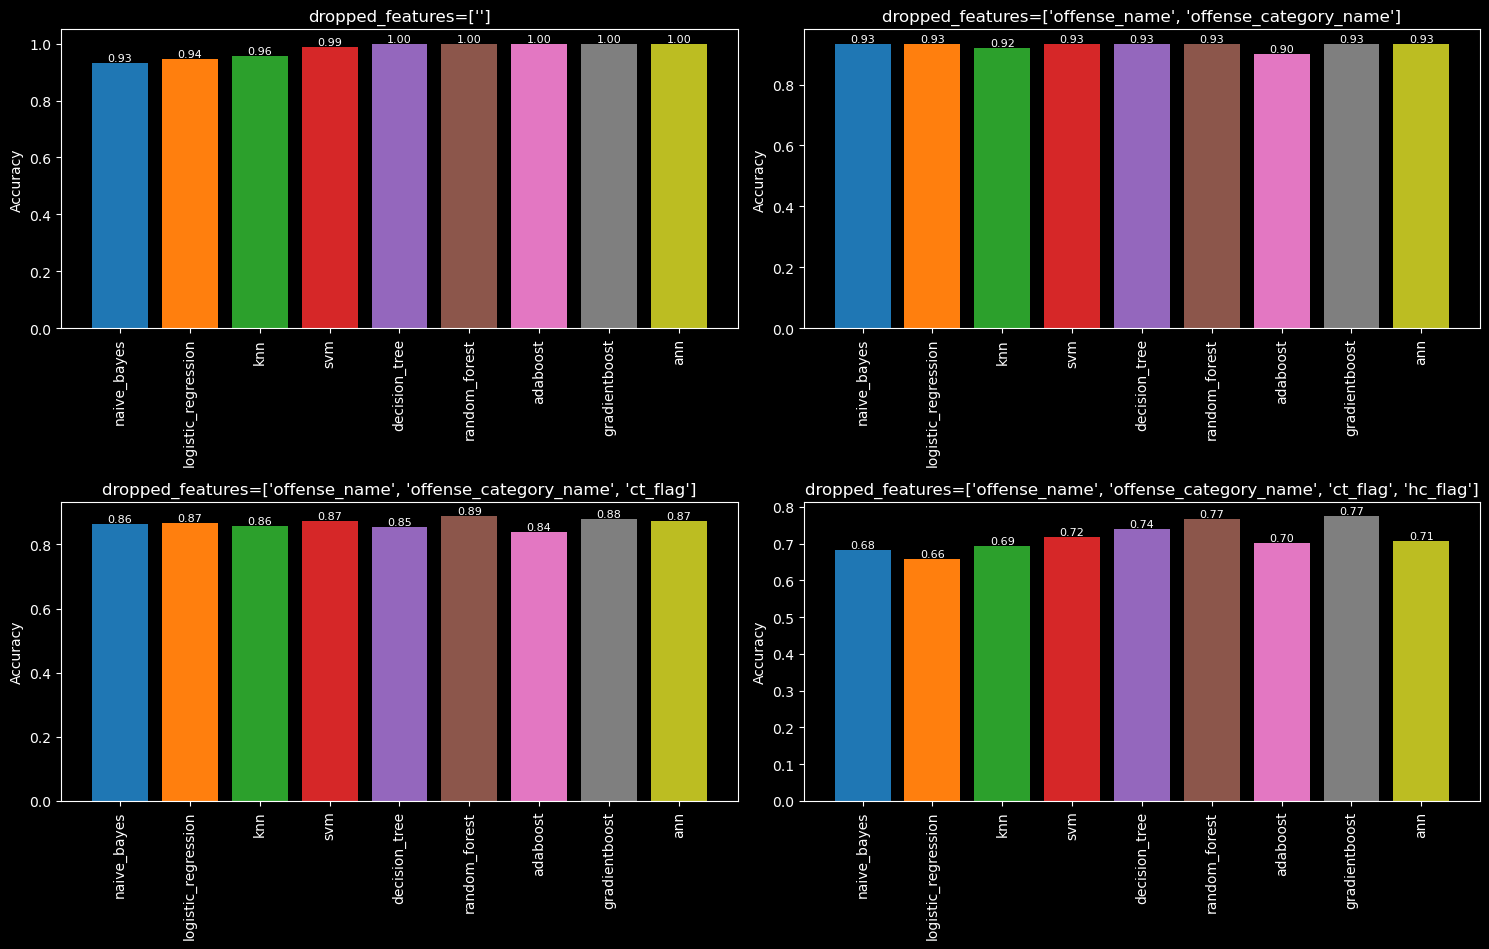

In [522]:
downsample_result = evaluate_and_plot(df_downsampled)

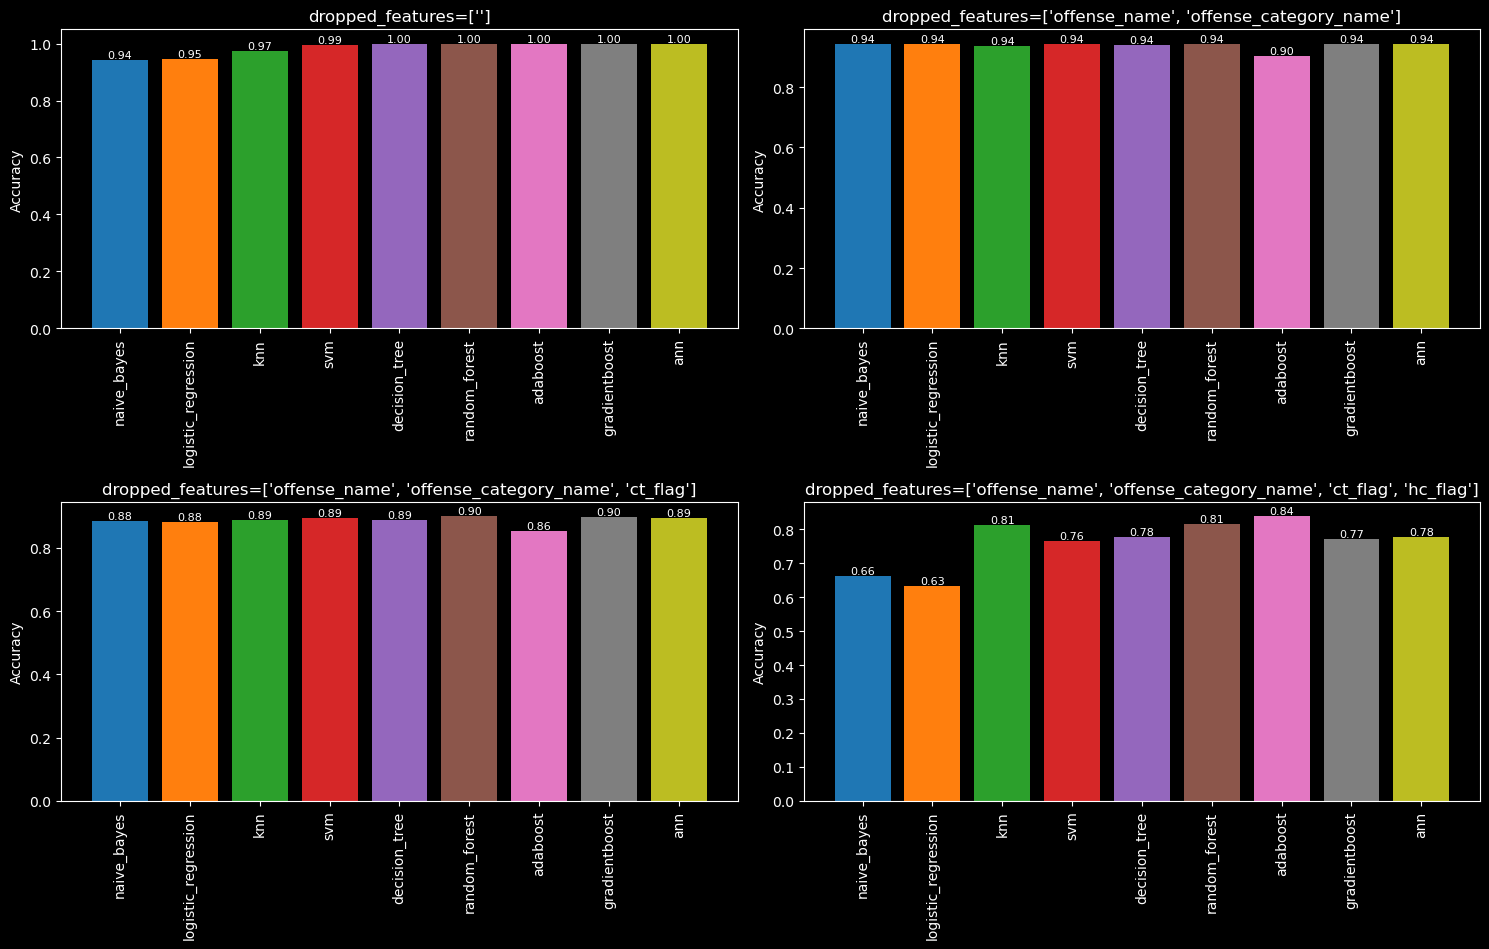

In [523]:
upsampled_result = evaluate_and_plot(df_upsampled)

In [536]:
df_upsampled['crime_against'].value_counts()

crime_against
1    41949
0    27767
Name: count, dtype: int64

#### Use cross validation to check the robustness of oversampling using dataframe sampling

Accuracy for Naive Bayes model 0.67
time elapsed for Naive Bayes: 0.03
Accuracy for Logistic Regression model 0.64
time elapsed for Logistic Regression: 0.77
Accuracy for KNN model 0.81
time elapsed for KNN: 2.17
Accuracy for Support vector classifier 0.76
time elapsed for Support Vector Machine: 82.94
Accuracy for Decision_tree 0.77
time elapsed for Decision Tree Classifier: 0.14
Accuracy for Random Forest 0.81
time elapsed for Random Forest Classifier: 6.65
Accuracy for Adaboost 0.84
time elapsed for Adaboost: 0.29
Accuracy for Gradient Boosting 0.78
time elapsed for Gradientboost: 5.75
Accuracy for ANN 0.78
time elapsed for ANN: 8.589420795440674
55772 13944
Accuracy for Naive Bayes model 0.67
time elapsed for Naive Bayes: 0.01
Accuracy for Logistic Regression model 0.64
time elapsed for Logistic Regression: 0.78
Accuracy for KNN model 0.81
time elapsed for KNN: 2.17
Accuracy for Support vector classifier 0.76
time elapsed for Support Vector Machine: 84.32
Accuracy for Decision_tree

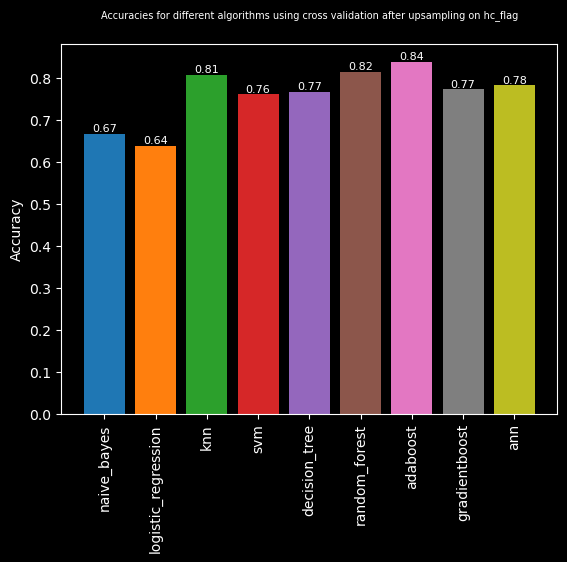

In [524]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mean_accuracies = []

X = df_upsampled.drop(drop_features, axis=1)
y = df_upsampled['crime_against']

for i, (train_index, test_index) in enumerate(kf.split(X)):
    # Split the data into training and testing sets using the indices provided by kf.split
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    upsampled_accuracies, upsampled_trained_models, upsampled_time_taken, upsampled_predictions, upsampled_test_values = \
    evaluate_algoritms(X_train, X_test, y_train, y_test, evaluate_params, checktime=120, dont_train=[], scale=True,verbose=True)
    
    print(len(X_train),len(X_test))

    mean_accuracies.append(upsampled_accuracies)

mean_accuracies = {model: sum(d[model] for d in mean_accuracies) / len(mean_accuracies) for model in mean_accuracies[0]}


bars = plt.bar(mean_accuracies.keys(), mean_accuracies.values(),color=[plt.get_cmap('tab20')(i) for i in range(0,2*len(mean_accuracies),2)])
ax = plt.gca()
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', rotation=90)  
ax.set_title("Accuracies for different algorithms using cross validation after upsampling on hc_flag",color='white',fontsize=7,y=1.05)
# ax.text(-0.65, 0.77, , fontsize=10)

for bar, acc in zip(bars, mean_accuracies.values()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{acc:.2f}', ha='center', va='bottom', fontsize=8)





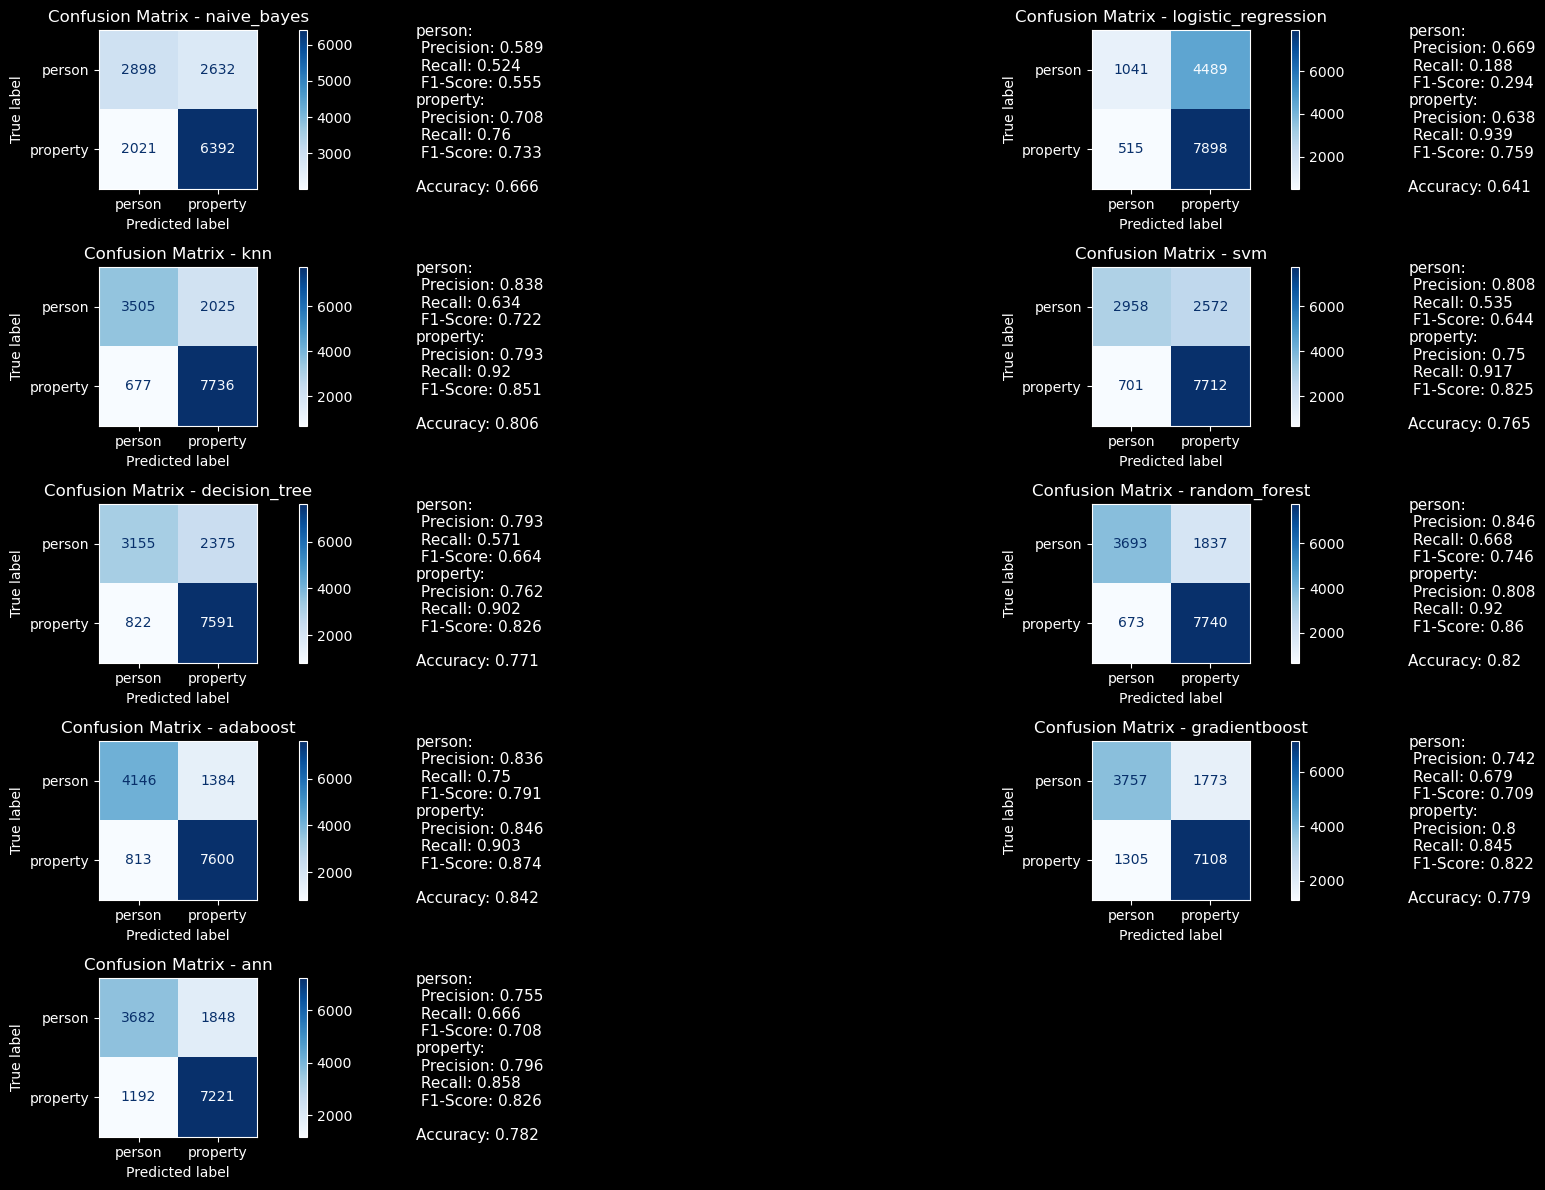

In [525]:
plot_confusion_matrix(df,upsampled_predictions,upsampled_test_values,display_cr=False)

#### Upsampling using SMOTE

In [526]:
from imblearn.over_sampling import SMOTE
X_train,y_train = SMOTE().fit_resample(X_train,y_train)

In [527]:
X_train.shape,y_train.shape

((67072, 14), (67072,))

In [528]:
y_train.value_counts()

crime_against
1    33536
0    33536
Name: count, dtype: int64

In [529]:
smote_accuracies, smote_trained_models, smote_time_taken, smote_predictions, smote_test_values = \
    evaluate_algoritms(X_train, X_test, y_train, y_test, evaluate_params, checktime=120, dont_train=[], scale=True)

Accuracy for Naive Bayes model 0.63
time elapsed for Naive Bayes: 0.02
Accuracy for Logistic Regression model 0.64
time elapsed for Logistic Regression: 0.89
Accuracy for KNN model 0.83
time elapsed for KNN: 2.53
Accuracy for Support vector classifier 0.77
time elapsed for Support Vector Machine: 103.6
Accuracy for Decision_tree 0.77
time elapsed for Decision Tree Classifier: 0.2
Accuracy for Random Forest 0.83
time elapsed for Random Forest Classifier: 9.22
Accuracy for Adaboost 0.85
time elapsed for Adaboost: 0.41
Accuracy for Gradient Boosting 0.77
time elapsed for Gradientboost: 7.97
Accuracy for ANN 0.78
time elapsed for ANN: 9.902744054794312


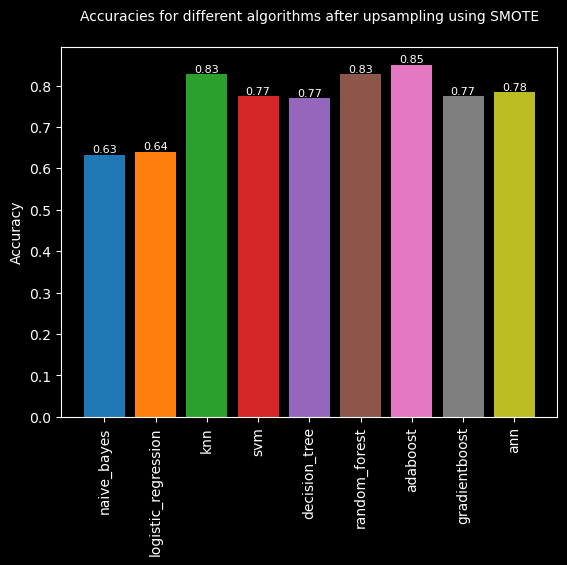

In [530]:
bars = plt.bar(smote_accuracies.keys(), smote_accuracies.values(),color=[plt.get_cmap('tab20')(i) for i in range(0,2*len(smote_accuracies),2)])
ax = plt.gca()
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', rotation=90)  
ax.set_title("Accuracies for different algorithms after upsampling using SMOTE",color='white',fontsize=10,y=1.05)
# ax.text(-0.65, 0.77, , fontsize=10)

for bar, acc in zip(bars, smote_accuracies.values()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{acc:.2f}', ha='center', va='bottom', fontsize=8)


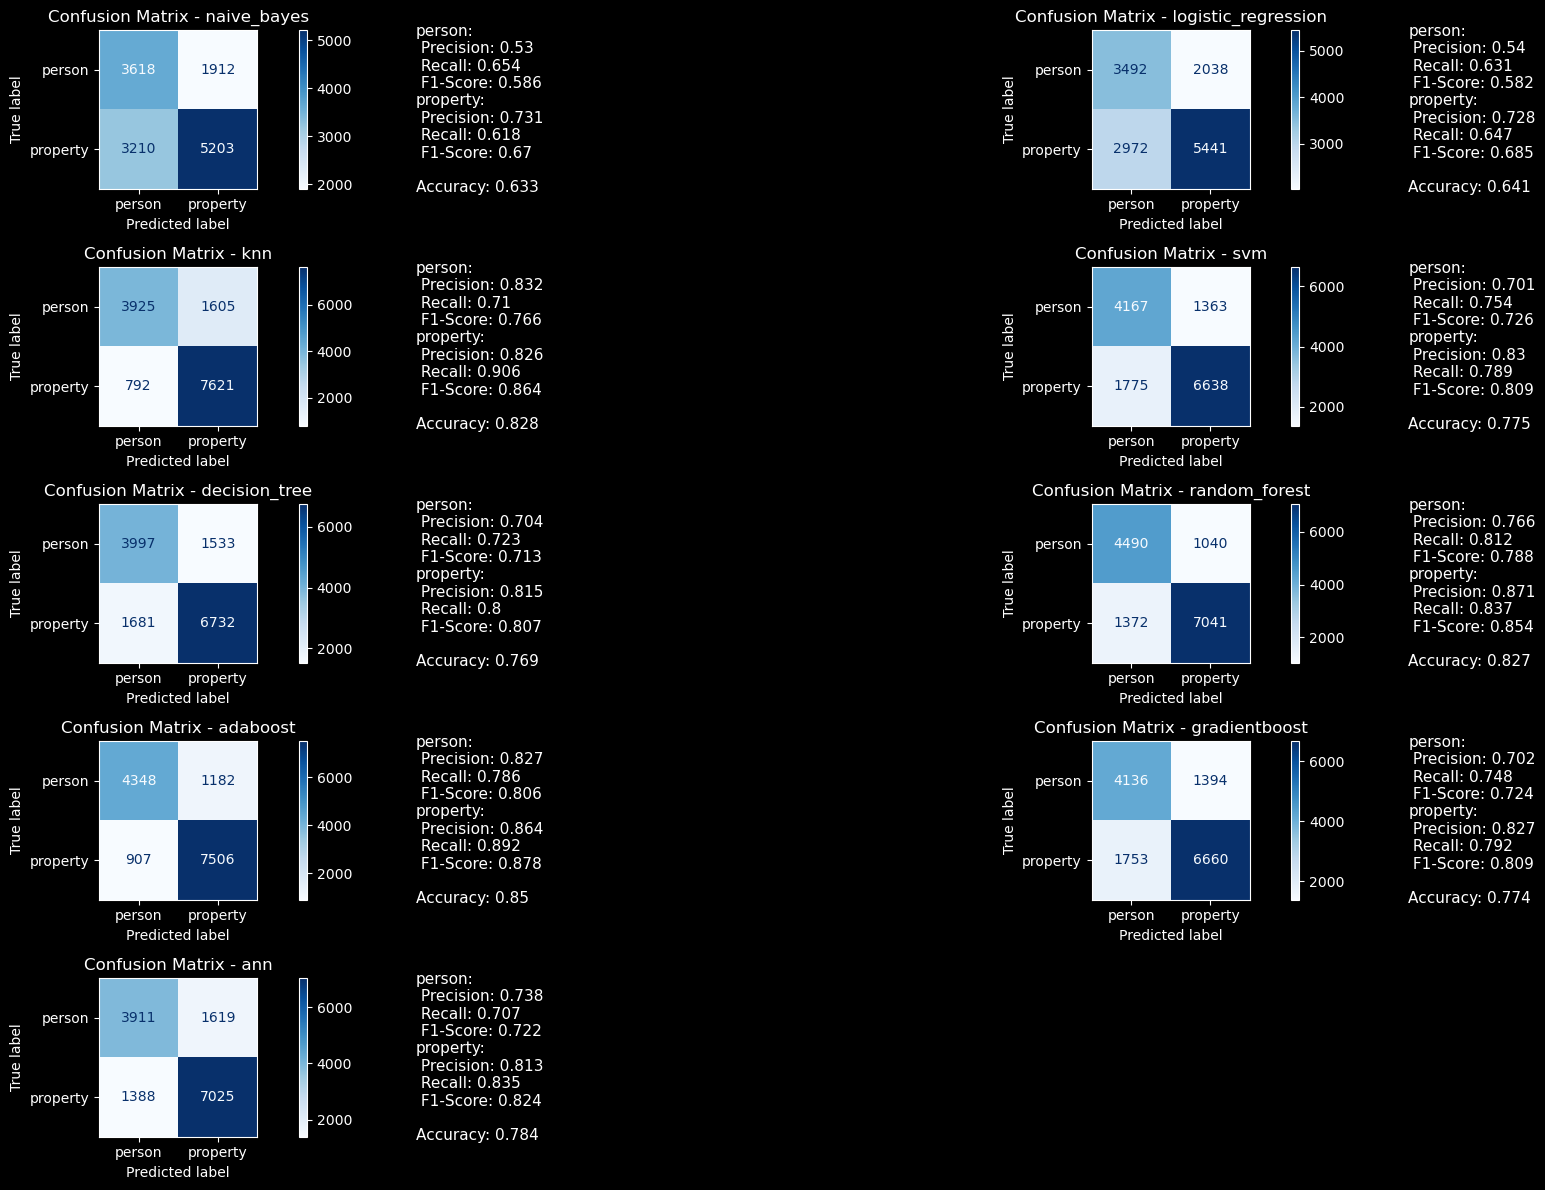

In [531]:
plot_confusion_matrix(df,smote_predictions,smote_test_values,display_cr=False)

In [532]:
# we can see there is no hate crime feature here still we got accuarcy of 90%
X_train.columns

Index(['relationship_name', 'victim_age', 'victim_race', 'victim_sex',
       'victim_ethnicity', 'offender_age', 'offender_sex',
       'offender_ethnicity', 'offender_race', 'location_name', 'incident_hour',
       'month_num', 'latitude', 'longitude'],
      dtype='object')

#### Let's test the data using Sythetic data generated using mockarro.com

In [533]:
df_syn = pd.read_csv('synthetic_data_cleaned.csv')
df_syn.head()

,victim_age,offender_age,incident_hour,latitude,longitude,month_num,relationship_name,victim_sex,offender_sex,victim_ethnicity,offender_ethnicity,victim_race,offender_race,location_name,offense_name,offense_category_name,crime_against,ct_flag,hc_flag
0,2.397895,4.043051,21,-74.06,39.74,4,0,1,0,1,1,5,2,24,22,4,1,True,True
1,3.496508,3.526361,4,-74.92,39.58,8,8,0,0,1,1,5,2,35,15,1,1,False,False
2,4.189655,3.218876,3,-74.73,39.78,6,15,0,0,0,0,2,2,35,30,2,1,False,True
3,4.543295,4.615121,12,-75.06,39.58,10,8,0,0,1,1,5,5,35,18,15,1,True,True
4,2.890372,4.043051,2,-75.39,39.79,12,7,0,0,1,1,5,5,16,16,4,1,True,True


In [534]:
X_test.columns

Index(['relationship_name', 'victim_age', 'victim_race', 'victim_sex',
       'victim_ethnicity', 'offender_age', 'offender_sex',
       'offender_ethnicity', 'offender_race', 'location_name', 'incident_hour',
       'month_num', 'latitude', 'longitude'],
      dtype='object')

In [554]:

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,classification_report


drop_features = ['offense_name','offense_category_name','ct_flag']
X_test = df_syn.drop(drop_features,axis=1)
y_test = df_syn['crime_against']

syn_accuracies = {}

# Reorder columns in X_test to match X_train
X_test = X_test[list(X_train.columns)]

for model_name,model in smote_trained_models.items():

    if model_name in ['svm','knn']:
        sc = StandardScaler()
        X_test_scaled = sc.fit_transform(X_test)
    else:
        X_test_scaled = X_test
    
    y_pred = model.predict(X_test_scaled)
    if model_name == 'ann':
        y_pred = np.round(y_pred.squeeze(),decimals=0)
        
    acc = np.mean(y_test==y_pred)
    syn_accuracies[model_name] = acc

    cr = classification_report(y_test,y_pred)
    cm = confusion_matrix(y_test,y_pred)
    print('\n',cr,'\n')     
    print('\n',cm)  


               precision    recall  f1-score   support

           0       0.45      0.40      0.43       468
           1       0.52      0.57      0.54       532

    accuracy                           0.49      1000
   macro avg       0.49      0.49      0.49      1000
weighted avg       0.49      0.49      0.49      1000
 


 [[189 279]
 [229 303]]

               precision    recall  f1-score   support

           0       0.46      0.59      0.52       468
           1       0.52      0.39      0.45       532

    accuracy                           0.49      1000
   macro avg       0.49      0.49      0.48      1000
weighted avg       0.49      0.49      0.48      1000
 


 [[277 191]
 [323 209]]

               precision    recall  f1-score   support

           0       0.47      0.61      0.53       468
           1       0.54      0.41      0.46       532

    accuracy                           0.50      1000
   macro avg       0.51      0.51      0.50      1000
weighted avg  

In [557]:
syn_accuracies

{'naive_bayes': 0.492,
 'logistic_regression': 0.486,
 'knn': 0.501,
 'svm': 0.496,
 'decision_tree': 0.478,
 'random_forest': 0.477,
 'adaboost': 0.512,
 'gradientboost': 0.486,
 'ann': 0.532}

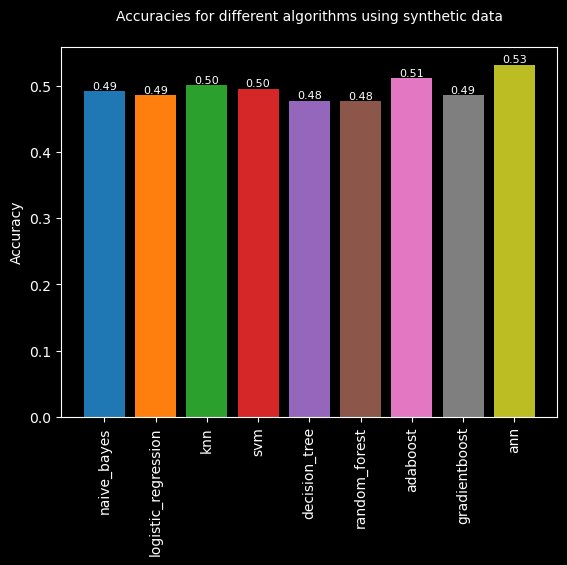

In [572]:
bars = plt.bar(syn_accuracies.keys(), syn_accuracies.values(),color=[plt.get_cmap('tab20')(i) for i in range(0,2*len(syn_accuracies),2)])
ax = plt.gca()
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', rotation=90)  
ax.set_title("Accuracies for different algorithms using synthetic data",color='white',fontsize=10,y=1.05)
# ax.text(-0.65, 0.77, , fontsize=10)

for bar, acc in zip(bars, syn_accuracies.values()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{acc:.2f}', ha='center', va='bottom', fontsize=8)


We can see the performance of the trained model on the synthetic data is random, this can clearly gives the difference in the real world data and the synthetic data, and how recreating the real world data is so tough